## LiH - Sampled-Based Quantum Diagonalization Liouville-Lanczos Galitskii-Migdal

This notebook presents the results obtained for Liouville–Lanczos and Galitskii–Migdal using the LiH molecule with different samples from the ground-state statevector.


In [1]:
# ===== System =====
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
import warnings

warnings.filterwarnings("ignore")

MAPPER = JordanWignerMapper()

n = 3
driver = PySCFDriver(
    atom="Li 0.0 0.0 0.0; H 0.0 0.0 1.6", basis="sto-3g", spin=0, charge=0
)
problem = driver.run()
transformer = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=n)
problem = transformer.transform(problem)
ferm_ham = problem.hamiltonian.second_q_op()

# mapping JW
hamiltonian = MAPPER.map(ferm_ham)

# matrice
Hmat = hamiltonian.to_matrix()
E, S = np.linalg.eigh(Hmat)
HAM = problem.hamiltonian
h0_tensor = HAM.electronic_integrals.one_body.alpha.to_dense()
h0 = h0_tensor["+-"]
h0 = np.array(h0)
id = np.argmin(E)
true_gs_energy = E[id]
true_gs_vector = S[:, id]
print("Exact ground state energy :",true_gs_energy)

Exact ground state energy : -8.854421336775156


---
### 1. We keep all bitstrings from the state vector with a coefficient greater than $10^{-5}$

In [2]:
# ===== SQD =====
from LiouvilleLanczos.Quantum_computer.sqd_lanczos import SampledSubspaceProjector

num_qubits = 2*n
treshold = 1e-5
mask = np.abs(true_gs_vector) > treshold
print(f"Number of significant bitstrings in the ground state: {np.sum(mask)}")

indices = np.where(mask)[0]
bitstrings = [format(i, f"0{num_qubits}b") for i in indices]
states = np.array([[int(b) for b in s] for s in bitstrings], dtype=int)
print(states)

eval = SampledSubspaceProjector(states)
H_tilde = eval.H_tilde_matrix(hamiltonian)
e, v = np.linalg.eig(H_tilde)
gs_energie = np.min(e).real
coeffs = v[:, np.argmin(e)]
print("Ground states energy from sampled states:", gs_energie)

Number of significant bitstrings in the ground state: 9
[[0 1 1 0 1 1]
 [0 1 1 1 0 1]
 [0 1 1 1 1 0]
 [1 0 1 0 1 1]
 [1 0 1 1 0 1]
 [1 0 1 1 1 0]
 [1 1 0 0 1 1]
 [1 1 0 1 0 1]
 [1 1 0 1 1 0]]
Ground states energy from sampled states: -8.854421336775156


early termination b at iteration 10
b^2=(2.356736826837082e-16+0j) is smaller than 1e-13, terminating
early termination b at iteration 10
b^2=(7.464881882394362e-15+0j) is smaller than 1e-13, terminating
early termination b at iteration 10
b^2=(1.1761967268208995e-14+0j) is smaller than 1e-13, terminating
early termination b at iteration 11
b^2=(-6.3765869140625+4.437022857404768e-30j) is smaller than 1e-13, terminating
early termination b at iteration 12
b^2=(-511.0625+1.336980567393619e-29j) is smaller than 1e-13, terminating
early termination b at iteration 10
b^2=(-0.52593994140625+2.466737091302248e-30j) is smaller than 1e-13, terminating


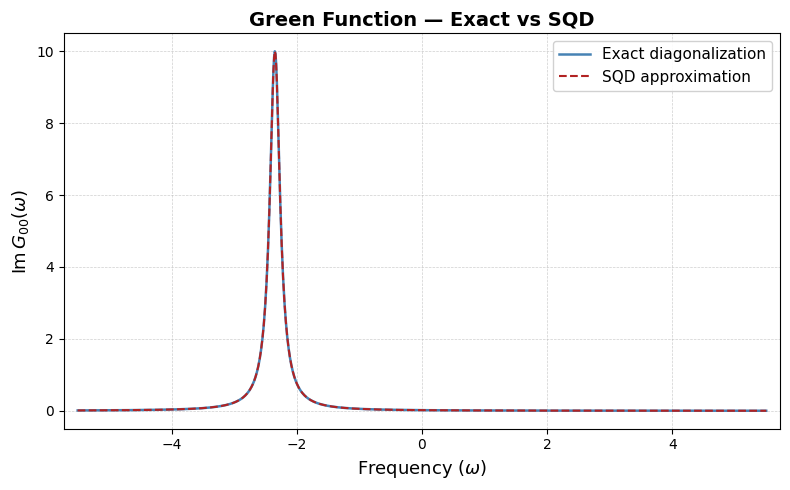

In [3]:
# ===== Liouville-Lanczos =====
from LiouvilleLanczos.Lanczos import Lanczos
from LiouvilleLanczos.Green import CF_Green, PolyLehmann_Green
from LiouvilleLanczos.matrix_impl import (
    MatrixState_inner_product,
    Matrix_Liouvillian,
    Matrix_sum,
)
from LiouvilleLanczos.Quantum_computer.QC_lanczos import Liouvillian_spo, sum_spo
from LiouvilleLanczos.Lanczos import Lanczos
from LiouvilleLanczos.Green import CF_Green, PolyLehmann_Green


def make_green_stack(
    opset_list=["0-123", "1-2"],
    max_iter=10,
    n=4,
    u=4,
    mu=None,
    energy=None,
    backend="exact",
    shots=np.inf,
    eps=1e-17,
    overwrite=False,
):
    stacked_green = None
    abm_dict = {}
    min_iter = 1
    for opset in opset_list:
        a, b, m = get_abmu(
            max_iter, n, u, mu, energy, backend, shots, eps, opset, overwrite
        )
        abm_dict[opset] = (a, b, m)
        min_iter = max(min_iter, len(a))

    for opset, (a, b, m) in abm_dict.items():
        green_list = make_green_list(a, b, m, min_iter)
        if stacked_green is None:
            stacked_green = green_list
        else:
            stacked_green = np.hstack(
                [stacked_green, green_list]
            )  # si ça converge plus vite que le critere on a un probleme
    return stacked_green  # 6 Green par 30it


def annihilation_operators(n):
    c_fermi_list = [
        FermionicOp({f"-_{i}": 1}, num_spin_orbitals=2 * n) for i in range(n)
    ]
    return [MAPPER.map(c) for c in c_fermi_list]


def get_abmu(
    max_iter=10,
    n=4,
    u=4,
    mu=None,
    energy=None,
    backend="exact",
    shots=np.inf,
    eps=1e-17,
    opset="0-123",
    overwrite=False,
):

    c_operators = annihilation_operators(n)

    main_i, other_i = opset.split("-")
    main_op = c_operators[int(main_i)]
    other_ops = [c_operators[int(i)] for i in other_i]

    if backend == "exact":
        _, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())
        ground_state = eigvecs[:, 0]
        lanczos = Lanczos(
            MatrixState_inner_product(ground_state),
            Matrix_Liouvillian(),
            Matrix_sum(),
            logger=None,
        )
        a, b, mm = lanczos.polynomial_hybrid(
            hamiltonian.to_matrix(),
            main_op.to_matrix(),
            [o.to_matrix() for o in other_ops],
            max_iter,
        )
        return a, b, mm

    if backend == "sqd":

        eval = SampledSubspaceProjector(states, coeffs, eps)
        avg_op = eval.inner_product_sqd
        SQ_Liou_avg = Liouvillian_spo(eps)
        lanczos = Lanczos(avg_op, SQ_Liou_avg, sum_spo(eps))

        a, b, mm = lanczos.polynomial_hybrid(
            hamiltonian,
            main_op,
            [o for o in other_ops],
            max_iter,
        )
        return a, b, mm


def make_green_list(a, b, mm, min_iter=1):
    mm = np.asarray(mm)
    num_iterations = len(a)
    num_k = max(num_iterations, min_iter)
    num_moments = len(mm[0])
    green_list = np.empty((num_k, num_moments + 1), dtype=object)
    for k in range(1, num_k + 1):
        kk = min(
            k, num_iterations
        )  ## fill the k > num_iteration with the converged CF_Green
        green_list[k - 1, 0] = CF_Green(a[:kk], b[:kk])
        green0 = green_list[k - 1, 0].to_Lehmann()
        for m in range(num_moments):
            green_list[k - 1, m + 1] = PolyLehmann_Green(
                a[:k], b[:k], mm[:k, m], green0
            )
    return green_list


true_stack_green = make_green_stack(
    ["0-12", "1-02", "2-01"], 31, n, backend="exact", eps=1e-17
)
sqd_stack_green = make_green_stack(
    ["0-12", "1-02", "2-01"], 31, n, backend="sqd", eps=1e-17
)

# ===== Plot Green fonction =====
green_ed = true_stack_green[0][0]
green_sqd = sqd_stack_green[0][0]

w = np.linspace(-5.5, 5.5, 1000) - 1e-1j
w_real = np.real(w)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    w_real,
    np.imag(green_ed(w)),
    color="steelblue",
    linewidth=1.8,
    label=r"Exact diagonalization",
)

ax.plot(
    w_real,
    np.imag(green_sqd(w)),
    color="firebrick",
    linewidth=1.5,
    linestyle="--",
    label=r"SQD approximation",
)

ax.set_xlabel(r"Frequency ($\omega$)", fontsize=13)
ax.set_ylabel(r"$\mathrm{Im}\, G_{00}(\omega)$", fontsize=13)
ax.set_title("Green Function — Exact vs SQD", fontsize=14, fontweight="bold")


ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)


ax.legend(fontsize=11, framealpha=0.9)


ax.margins(x=0.02)

fig.tight_layout()
# plt.savefig("green_function_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

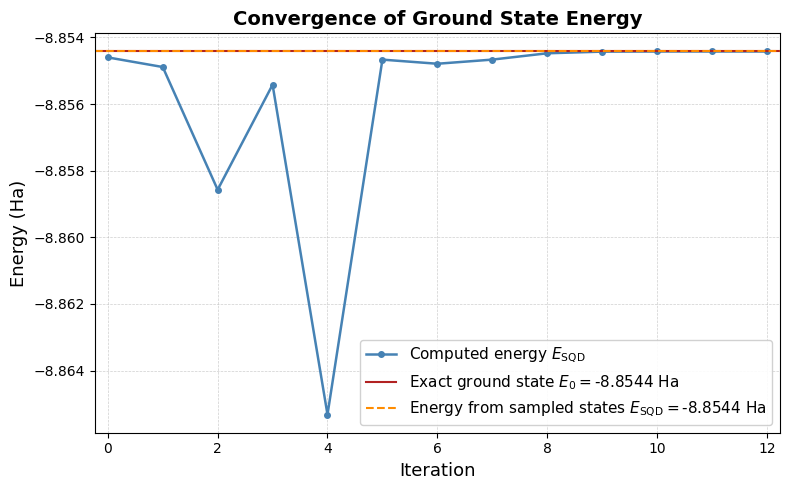

In [6]:
# ===== Galistkii-Migdal =====
from scipy.sparse import csr_array


def fermi(w):
    return w <= 0.0


green = sqd_stack_green


green_mapping_LiH = [
    (0, 0, 0, 1),
    (0, 1, 1, 1),
    (0, 2, 2, 1),
    (1, 0, 4, 1),
    (1, 1, 3, 1),
    (1, 2, 5, 1),
    (2, 0, 7, 1),
    (2, 1, 8, 1),
    (2, 2, 6, 1),
]

# Galitskii_Migdal_energy
n = len(h0)
num_iterations = len(green)
energy = []
for k in range(0, num_iterations):
    green_list = [g for g in green[k, :]]
    mapping_line = green_mapping_LiH

    # prepare_position_maps
    def convert_matpos(mat_pos):
        r, c, k = mat_pos
        assert r < n
        assert c < n
        assert k < len(green_list)
        return r + c * n, k

    R, C, D = (
        np.zeros(len(mapping_line), dtype=np.int64),
        np.zeros(len(mapping_line), dtype=np.int64),
        np.zeros(len(mapping_line), dtype=np.complex128),
    )
    for i, (il, jl, kl, coeff) in enumerate(mapping_line):
        R[i], C[i] = convert_matpos((il, jl, kl))
        D[i] = coeff
    position_maps = csr_array((D, (R, C)), shape=(n**2, len(green_list)))

    scalar_frequency_weights_function = lambda x: fermi(x)
    matrix_frequency_constant = h0
    GI = np.zeros(len(green_list))
    for i, g in enumerate(green_list):
        if not hasattr(g, "integrate"):
            g = g.to_Lehmann()
        GI[i] = g.integrate(scalar_frequency_weights_function)
    fm = matrix_frequency_constant.flatten()
    Kq = fm @ position_maps @ GI

    scalar_frequency_weights_function = lambda x: x * fermi(x)
    matrix_frequency_constant = np.eye(n)
    GI = np.zeros(len(green_list))
    for i, g in enumerate(green_list):
        if not hasattr(g, "integrate"):
            g = g.to_Lehmann()
        GI[i] = g.integrate(scalar_frequency_weights_function)
    fm = matrix_frequency_constant.flatten()
    wG = fm @ position_maps @ GI

    energy.append((wG + Kq).real)  # /2 missing because spin degeneracy

true_gm_energy = energy


# ===== Plot G-M =====
iterations = np.arange(len(true_gm_energy))

fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(
    iterations,
    true_gm_energy,
    color="steelblue",
    linewidth=1.8,
    marker="o",
    markersize=4,
    label=r"Computed energy $E_{\mathrm{SQD}}$",
)


ax.axhline(
    y=true_gs_energy,
    color="firebrick",
    linewidth=1.5,
    label=r"Exact ground state $E_0 = $" + f"{true_gs_energy:.4f} Ha",
)

ax.axhline(
    y=gs_energie,
    color="darkorange",
    linewidth=1.5,
    linestyle="--",
    label=r"Energy from sampled states $E_{\mathrm{SQD}} = $" + f"{gs_energie:.4f} Ha",
)


ax.set_xlabel("Iteration", fontsize=13)
ax.set_ylabel("Energy (Ha)", fontsize=13)
ax.set_title("Convergence of Ground State Energy", fontsize=14, fontweight="bold")


ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)


ax.legend(fontsize=11, framealpha=0.9)


ax.margins(x=0.02)

fig.tight_layout()
# plt.savefig("energy_convergence.pdf", dpi=300, bbox_inches="tight")
plt.show()

---

### 2. We sample 1 000 measures from the statevector 

In [7]:
# ===== SQD =====
from qiskit.quantum_info import Statevector
from LiouvilleLanczos.Quantum_computer.sqd_lanczos import SampledSubspaceProjector

gs_id = np.argmin(E)
sv = Statevector(true_gs_vector)
sv.seed(42)
shots = 1000
samples = sv.sample_counts(shots)
bitstrings = list(samples.keys())
states = np.array([[int(b) for b in s[::-1]] for s in bitstrings], dtype=int) # Fallait tenir compte du little-endian
print(states)

eval = SampledSubspaceProjector(states)
H_tilde = eval.H_tilde_matrix(hamiltonian)
e, v = np.linalg.eig(H_tilde)
gs_energie = np.min(e).real
coeffs = v[:, np.argmin(e)]
print("Energy from sampled states:", gs_energie)

[[1 1 0 1 1 0]]
Energy from sampled states: -8.854072040283643


early termination b at iteration 10
b^2=(2.356736826837082e-16+0j) is smaller than 1e-13, terminating
early termination b at iteration 10
b^2=(7.464881882394362e-15+0j) is smaller than 1e-13, terminating
early termination b at iteration 10
b^2=(1.1761967268208995e-14+0j) is smaller than 1e-13, terminating


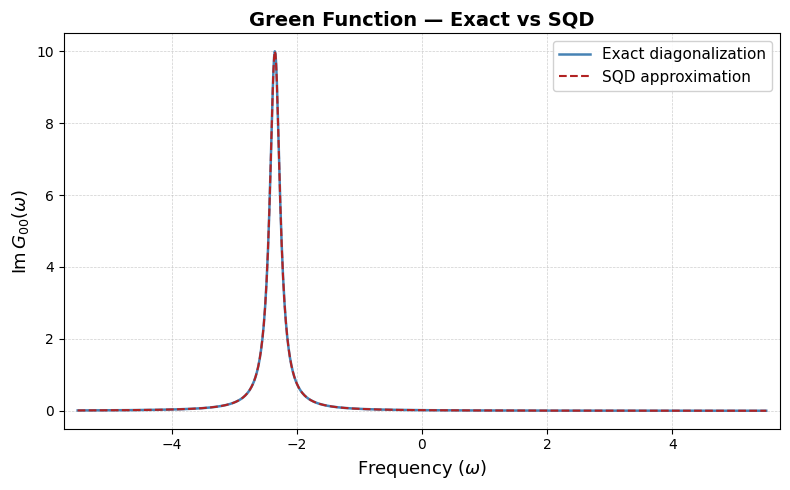

In [8]:
# ===== Liouville-Lanczos =====
from LiouvilleLanczos.Lanczos import Lanczos
from LiouvilleLanczos.Green import CF_Green, PolyLehmann_Green
from LiouvilleLanczos.matrix_impl import (
    MatrixState_inner_product,
    Matrix_Liouvillian,
    Matrix_sum,
)
from LiouvilleLanczos.Quantum_computer.QC_lanczos import Liouvillian_spo, sum_spo
from LiouvilleLanczos.Lanczos import Lanczos
from LiouvilleLanczos.Green import CF_Green, PolyLehmann_Green


def make_green_stack(
    opset_list=["0-123", "1-2"],
    max_iter=10,
    n=4,
    u=4,
    mu=None,
    energy=None,
    backend="exact",
    shots=np.inf,
    eps=1e-17,
    overwrite=False,
):
    stacked_green = None
    abm_dict = {}
    min_iter = 1
    for opset in opset_list:
        a, b, m = get_abmu(
            max_iter, n, u, mu, energy, backend, shots, eps, opset, overwrite
        )
        abm_dict[opset] = (a, b, m)
        min_iter = max(min_iter, len(a))

    for opset, (a, b, m) in abm_dict.items():
        green_list = make_green_list(a, b, m, min_iter)
        if stacked_green is None:
            stacked_green = green_list
        else:
            stacked_green = np.hstack(
                [stacked_green, green_list]
            )  # si ça converge plus vite que le critere on a un probleme
    return stacked_green  # 6 Green par 30it


def annihilation_operators(n):
    c_fermi_list = [
        FermionicOp({f"-_{i}": 1}, num_spin_orbitals=2 * n) for i in range(n)
    ]
    return [MAPPER.map(c) for c in c_fermi_list]


def get_abmu(
    max_iter=10,
    n=4,
    u=4,
    mu=None,
    energy=None,
    backend="exact",
    shots=np.inf,
    eps=1e-17,
    opset="0-123",
    overwrite=False,
):

    c_operators = annihilation_operators(n)

    main_i, other_i = opset.split("-")
    main_op = c_operators[int(main_i)]
    other_ops = [c_operators[int(i)] for i in other_i]

    if backend == "exact":
        _, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())
        ground_state = eigvecs[:, 0]
        lanczos = Lanczos(
            MatrixState_inner_product(ground_state),
            Matrix_Liouvillian(),
            Matrix_sum(),
            logger=None,
        )
        a, b, mm = lanczos.polynomial_hybrid(
            hamiltonian.to_matrix(),
            main_op.to_matrix(),
            [o.to_matrix() for o in other_ops],
            max_iter,
        )
        return a, b, mm

    if backend == "sqd":

        eval = SampledSubspaceProjector(states, coeffs, eps)
        avg_op = eval.inner_product_sqd
        SQ_Liou_avg = Liouvillian_spo(eps)
        lanczos = Lanczos(avg_op, SQ_Liou_avg, sum_spo(eps))

        a, b, mm = lanczos.polynomial_hybrid(
            hamiltonian,
            main_op,
            [o for o in other_ops],
            max_iter,
        )
        return a, b, mm


def make_green_list(a, b, mm, min_iter=1):
    mm = np.asarray(mm)
    num_iterations = len(a)
    num_k = max(num_iterations, min_iter)
    num_moments = len(mm[0])
    green_list = np.empty((num_k, num_moments + 1), dtype=object)
    for k in range(1, num_k + 1):
        kk = min(
            k, num_iterations
        )  ## fill the k > num_iteration with the converged CF_Green
        green_list[k - 1, 0] = CF_Green(a[:kk], b[:kk])
        green0 = green_list[k - 1, 0].to_Lehmann()
        for m in range(num_moments):
            green_list[k - 1, m + 1] = PolyLehmann_Green(
                a[:k], b[:k], mm[:k, m], green0
            )
    return green_list


true_stack_green = make_green_stack(
    ["0-12", "1-02", "2-01"], 31, n, backend="exact", eps=1e-17
)
sqd_stack_green = make_green_stack(
    ["0-12", "1-02", "2-01"], 31, n, backend="sqd", eps=1e-17
)

# ===== Plot Green fonction =====
green_ed = true_stack_green[0][0]
green_sqd = sqd_stack_green[0][0]

w = np.linspace(-5.5, 5.5, 1000) - 1e-1j
w_real = np.real(w)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    w_real,
    np.imag(green_ed(w)),
    color="steelblue",
    linewidth=1.8,
    label=r"Exact diagonalization",
)

ax.plot(
    w_real,
    np.imag(green_sqd(w)),
    color="firebrick",
    linewidth=1.5,
    linestyle="--",
    label=r"SQD approximation",
)

ax.set_xlabel(r"Frequency ($\omega$)", fontsize=13)
ax.set_ylabel(r"$\mathrm{Im}\, G_{00}(\omega)$", fontsize=13)
ax.set_title("Green Function — Exact vs SQD", fontsize=14, fontweight="bold")


ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)


ax.legend(fontsize=11, framealpha=0.9)


ax.margins(x=0.02)

fig.tight_layout()
# plt.savefig("green_function_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

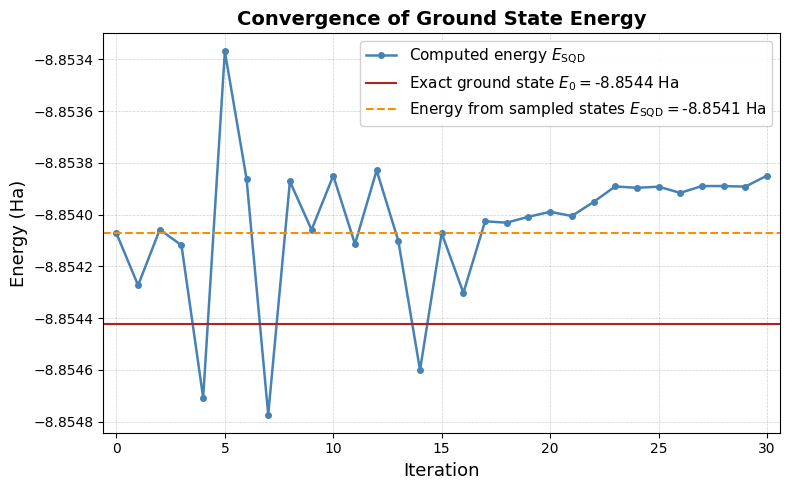

In [9]:
# ===== Galistkii-Migdal =====
from scipy.sparse import csr_array


def fermi(w):
    return w <= 0.0


green = sqd_stack_green


green_mapping_LiH = [
    (0, 0, 0, 1),
    (0, 1, 1, 1),
    (0, 2, 2, 1),
    (1, 0, 4, 1),
    (1, 1, 3, 1),
    (1, 2, 5, 1),
    (2, 0, 7, 1),
    (2, 1, 8, 1),
    (2, 2, 6, 1),
]

# Galitskii_Migdal_energy
n = len(h0)
num_iterations = len(green)
energy = []
for k in range(0, num_iterations):
    green_list = [g for g in green[k, :]]
    mapping_line = green_mapping_LiH

    # prepare_position_maps
    def convert_matpos(mat_pos):
        r, c, k = mat_pos
        assert r < n
        assert c < n
        assert k < len(green_list)
        return r + c * n, k

    R, C, D = (
        np.zeros(len(mapping_line), dtype=np.int64),
        np.zeros(len(mapping_line), dtype=np.int64),
        np.zeros(len(mapping_line), dtype=np.complex128),
    )
    for i, (il, jl, kl, coeff) in enumerate(mapping_line):
        R[i], C[i] = convert_matpos((il, jl, kl))
        D[i] = coeff
    position_maps = csr_array((D, (R, C)), shape=(n**2, len(green_list)))

    scalar_frequency_weights_function = lambda x: fermi(x)
    matrix_frequency_constant = h0
    GI = np.zeros(len(green_list))
    for i, g in enumerate(green_list):
        if not hasattr(g, "integrate"):
            g = g.to_Lehmann()
        GI[i] = g.integrate(scalar_frequency_weights_function)
    fm = matrix_frequency_constant.flatten()
    Kq = fm @ position_maps @ GI

    scalar_frequency_weights_function = lambda x: x * fermi(x)
    matrix_frequency_constant = np.eye(n)
    GI = np.zeros(len(green_list))
    for i, g in enumerate(green_list):
        if not hasattr(g, "integrate"):
            g = g.to_Lehmann()
        GI[i] = g.integrate(scalar_frequency_weights_function)
    fm = matrix_frequency_constant.flatten()
    wG = fm @ position_maps @ GI

    energy.append((wG + Kq).real)  # /2 missing because spin degeneracy

true_gm_energy = energy


# ===== Plot G-M =====
iterations = np.arange(len(true_gm_energy))

fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(
    iterations,
    true_gm_energy,
    color="steelblue",
    linewidth=1.8,
    marker="o",
    markersize=4,
    label=r"Computed energy $E_{\mathrm{SQD}}$",
)


ax.axhline(
    y=true_gs_energy,
    color="firebrick",
    linewidth=1.5,
    label=r"Exact ground state $E_0 = $" + f"{true_gs_energy:.4f} Ha",
)

ax.axhline(
    y=gs_energie,
    color="darkorange",
    linewidth=1.5,
    linestyle="--",
    label=r"Energy from sampled states $E_{\mathrm{SQD}} = $" + f"{gs_energie:.4f} Ha",
)


ax.set_xlabel("Iteration", fontsize=13)
ax.set_ylabel("Energy (Ha)", fontsize=13)
ax.set_title("Convergence of Ground State Energy", fontsize=14, fontweight="bold")


ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)


ax.legend(fontsize=11, framealpha=0.9)


ax.margins(x=0.02)

fig.tight_layout()
# plt.savefig("energy_convergence.pdf", dpi=300, bbox_inches="tight")
plt.show()

---
### 3. Like the previous sampling but we forgot that Qiskit uses big-endian convention

In [10]:
# ===== SQD =====
from qiskit.quantum_info import Statevector
from LiouvilleLanczos.Quantum_computer.sqd_lanczos import SampledSubspaceProjector

gs_id = np.argmin(E)
sv = Statevector(true_gs_vector)
sv.seed(42)
shots = 1000
samples = sv.sample_counts(shots)
bitstrings = list(samples.keys())
states = np.array([[int(b) for b in s] for s in bitstrings], dtype=int) # Fallait tenir compte du little-endian
print(states)

eval = SampledSubspaceProjector(states)
H_tilde = eval.H_tilde_matrix(hamiltonian)
e, v = np.linalg.eig(H_tilde)
gs_energie = np.min(e).real
coeffs = v[:, np.argmin(e)]
print("Energy from sampled states:", gs_energie)

[[0 1 1 0 1 1]]
Energy from sampled states: -3.5428764686509377


early termination b at iteration 10
b^2=(2.356736826837082e-16+0j) is smaller than 1e-13, terminating
early termination b at iteration 10
b^2=(7.464881882394362e-15+0j) is smaller than 1e-13, terminating
early termination b at iteration 10
b^2=(1.1761967268208995e-14+0j) is smaller than 1e-13, terminating


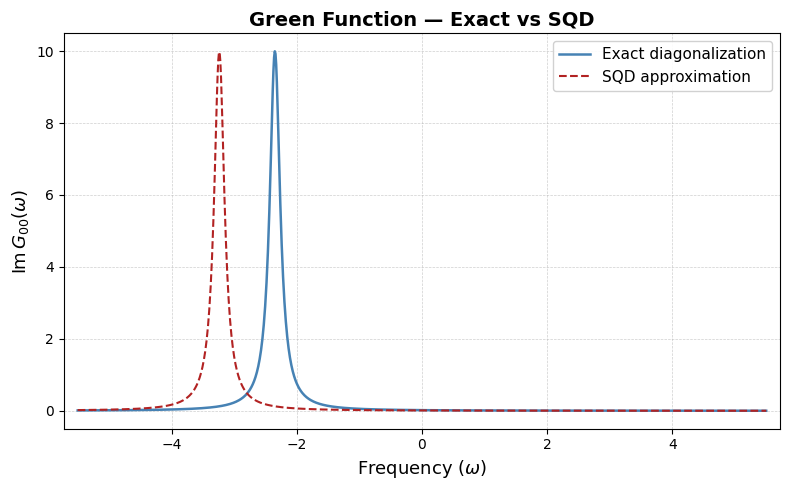

In [11]:
# ===== Liouville-Lanczos =====
from LiouvilleLanczos.Lanczos import Lanczos
from LiouvilleLanczos.Green import CF_Green, PolyLehmann_Green
from LiouvilleLanczos.matrix_impl import (
    MatrixState_inner_product,
    Matrix_Liouvillian,
    Matrix_sum,
)
from LiouvilleLanczos.Quantum_computer.QC_lanczos import Liouvillian_spo, sum_spo
from LiouvilleLanczos.Lanczos import Lanczos
from LiouvilleLanczos.Green import CF_Green, PolyLehmann_Green


def make_green_stack(
    opset_list=["0-123", "1-2"],
    max_iter=10,
    n=4,
    u=4,
    mu=None,
    energy=None,
    backend="exact",
    shots=np.inf,
    eps=1e-17,
    overwrite=False,
):
    stacked_green = None
    abm_dict = {}
    min_iter = 1
    for opset in opset_list:
        a, b, m = get_abmu(
            max_iter, n, u, mu, energy, backend, shots, eps, opset, overwrite
        )
        abm_dict[opset] = (a, b, m)
        min_iter = max(min_iter, len(a))

    for opset, (a, b, m) in abm_dict.items():
        green_list = make_green_list(a, b, m, min_iter)
        if stacked_green is None:
            stacked_green = green_list
        else:
            stacked_green = np.hstack(
                [stacked_green, green_list]
            )  # si ça converge plus vite que le critere on a un probleme
    return stacked_green  # 6 Green par 30it


def annihilation_operators(n):
    c_fermi_list = [
        FermionicOp({f"-_{i}": 1}, num_spin_orbitals=2 * n) for i in range(n)
    ]
    return [MAPPER.map(c) for c in c_fermi_list]


def get_abmu(
    max_iter=10,
    n=4,
    u=4,
    mu=None,
    energy=None,
    backend="exact",
    shots=np.inf,
    eps=1e-17,
    opset="0-123",
    overwrite=False,
):

    c_operators = annihilation_operators(n)

    main_i, other_i = opset.split("-")
    main_op = c_operators[int(main_i)]
    other_ops = [c_operators[int(i)] for i in other_i]

    if backend == "exact":
        _, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())
        ground_state = eigvecs[:, 0]
        lanczos = Lanczos(
            MatrixState_inner_product(ground_state),
            Matrix_Liouvillian(),
            Matrix_sum(),
            logger=None,
        )
        a, b, mm = lanczos.polynomial_hybrid(
            hamiltonian.to_matrix(),
            main_op.to_matrix(),
            [o.to_matrix() for o in other_ops],
            max_iter,
        )
        return a, b, mm

    if backend == "sqd":

        eval = SampledSubspaceProjector(states, coeffs, eps)
        avg_op = eval.inner_product_sqd
        SQ_Liou_avg = Liouvillian_spo(eps)
        lanczos = Lanczos(avg_op, SQ_Liou_avg, sum_spo(eps))

        a, b, mm = lanczos.polynomial_hybrid(
            hamiltonian,
            main_op,
            [o for o in other_ops],
            max_iter,
        )
        return a, b, mm


def make_green_list(a, b, mm, min_iter=1):
    mm = np.asarray(mm)
    num_iterations = len(a)
    num_k = max(num_iterations, min_iter)
    num_moments = len(mm[0])
    green_list = np.empty((num_k, num_moments + 1), dtype=object)
    for k in range(1, num_k + 1):
        kk = min(
            k, num_iterations
        )  ## fill the k > num_iteration with the converged CF_Green
        green_list[k - 1, 0] = CF_Green(a[:kk], b[:kk])
        green0 = green_list[k - 1, 0].to_Lehmann()
        for m in range(num_moments):
            green_list[k - 1, m + 1] = PolyLehmann_Green(
                a[:k], b[:k], mm[:k, m], green0
            )
    return green_list


true_stack_green = make_green_stack(
    ["0-12", "1-02", "2-01"], 31, n, backend="exact", eps=1e-17
)
sqd_stack_green = make_green_stack(
    ["0-12", "1-02", "2-01"], 31, n, backend="sqd", eps=1e-17
)

# ===== Plot Green fonction =====
green_ed = true_stack_green[0][0]
green_sqd = sqd_stack_green[0][0]

w = np.linspace(-5.5, 5.5, 1000) - 1e-1j
w_real = np.real(w)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    w_real,
    np.imag(green_ed(w)),
    color="steelblue",
    linewidth=1.8,
    label=r"Exact diagonalization",
)

ax.plot(
    w_real,
    np.imag(green_sqd(w)),
    color="firebrick",
    linewidth=1.5,
    linestyle="--",
    label=r"SQD approximation",
)

ax.set_xlabel(r"Frequency ($\omega$)", fontsize=13)
ax.set_ylabel(r"$\mathrm{Im}\, G_{00}(\omega)$", fontsize=13)
ax.set_title("Green Function — Exact vs SQD", fontsize=14, fontweight="bold")


ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)


ax.legend(fontsize=11, framealpha=0.9)


ax.margins(x=0.02)

fig.tight_layout()
# plt.savefig("green_function_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

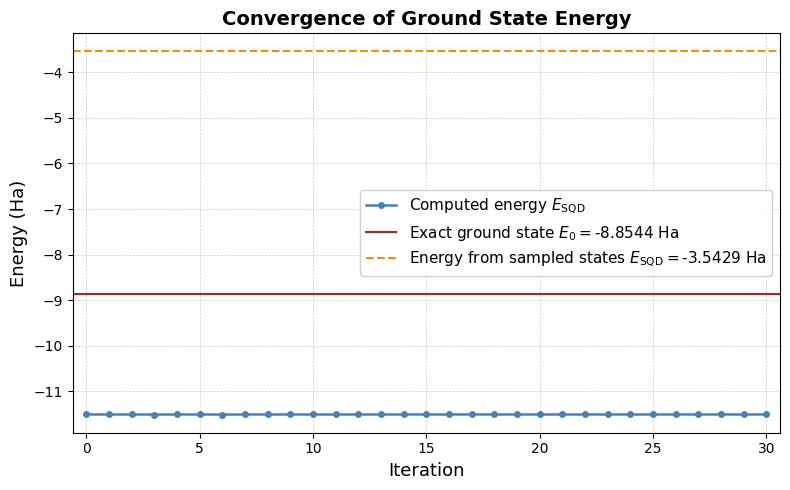

In [12]:
# ===== Galistkii-Migdal =====
from scipy.sparse import csr_array


def fermi(w):
    return w <= 0.0


green = sqd_stack_green


green_mapping_LiH = [
    (0, 0, 0, 1),
    (0, 1, 1, 1),
    (0, 2, 2, 1),
    (1, 0, 4, 1),
    (1, 1, 3, 1),
    (1, 2, 5, 1),
    (2, 0, 7, 1),
    (2, 1, 8, 1),
    (2, 2, 6, 1),
]

# Galitskii_Migdal_energy
n = len(h0)
num_iterations = len(green)
energy = []
for k in range(0, num_iterations):
    green_list = [g for g in green[k, :]]
    mapping_line = green_mapping_LiH

    # prepare_position_maps
    def convert_matpos(mat_pos):
        r, c, k = mat_pos
        assert r < n
        assert c < n
        assert k < len(green_list)
        return r + c * n, k

    R, C, D = (
        np.zeros(len(mapping_line), dtype=np.int64),
        np.zeros(len(mapping_line), dtype=np.int64),
        np.zeros(len(mapping_line), dtype=np.complex128),
    )
    for i, (il, jl, kl, coeff) in enumerate(mapping_line):
        R[i], C[i] = convert_matpos((il, jl, kl))
        D[i] = coeff
    position_maps = csr_array((D, (R, C)), shape=(n**2, len(green_list)))

    scalar_frequency_weights_function = lambda x: fermi(x)
    matrix_frequency_constant = h0
    GI = np.zeros(len(green_list))
    for i, g in enumerate(green_list):
        if not hasattr(g, "integrate"):
            g = g.to_Lehmann()
        GI[i] = g.integrate(scalar_frequency_weights_function)
    fm = matrix_frequency_constant.flatten()
    Kq = fm @ position_maps @ GI

    scalar_frequency_weights_function = lambda x: x * fermi(x)
    matrix_frequency_constant = np.eye(n)
    GI = np.zeros(len(green_list))
    for i, g in enumerate(green_list):
        if not hasattr(g, "integrate"):
            g = g.to_Lehmann()
        GI[i] = g.integrate(scalar_frequency_weights_function)
    fm = matrix_frequency_constant.flatten()
    wG = fm @ position_maps @ GI

    energy.append((wG + Kq).real)  # /2 missing because spin degeneracy

true_gm_energy = energy


# ===== Plot G-M =====
iterations = np.arange(len(true_gm_energy))

fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(
    iterations,
    true_gm_energy,
    color="steelblue",
    linewidth=1.8,
    marker="o",
    markersize=4,
    label=r"Computed energy $E_{\mathrm{SQD}}$",
)


ax.axhline(
    y=true_gs_energy,
    color="firebrick",
    linewidth=1.5,
    label=r"Exact ground state $E_0 = $" + f"{true_gs_energy:.4f} Ha",
)

ax.axhline(
    y=gs_energie,
    color="darkorange",
    linewidth=1.5,
    linestyle="--",
    label=r"Energy from sampled states $E_{\mathrm{SQD}} = $" + f"{gs_energie:.4f} Ha",
)


ax.set_xlabel("Iteration", fontsize=13)
ax.set_ylabel("Energy (Ha)", fontsize=13)
ax.set_title("Convergence of Ground State Energy", fontsize=14, fontweight="bold")


ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)


ax.legend(fontsize=11, framealpha=0.9)


ax.margins(x=0.02)

fig.tight_layout()
# plt.savefig("energy_convergence.pdf", dpi=300, bbox_inches="tight")
plt.show()

---
### 4. Sampling on quantum computer IBM_Quebec
We keep bitstrings with a Hamming weight corresponding to the number of electron (4 - LiH)

In [17]:
# ===== Sample states on quantum computer =====
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.primitives import StatevectorEstimator as pEstimator
from qiskit_algorithms import VQE
from qiskit.circuit.library import real_amplitudes
from qiskit import QuantumCircuit, transpile
from qiskit_algorithms.optimizers import COBYLA

service = QiskitRuntimeService()
backend = service.backends()[0]
print(f"Using backend: {backend.name}")
num_qubits = 2*n

ansatz = QuantumCircuit(num_qubits)
for q in range(num_qubits):
    ansatz.x(q)
ansatz = real_amplitudes(num_qubits=num_qubits, entanglement="linear")
ansatz.compose(ansatz, inplace=True)
optimizer = COBYLA(maxiter=1000)
estimator = pEstimator()
vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
result = vqe.compute_minimum_eigenvalue(hamiltonian)
optimal_params = result.optimal_parameters
energie = result.eigenvalue.real

qc = ansatz.assign_parameters(optimal_params)
qc.measure_all()
qc = transpile(qc, backend)
sampler = Sampler(mode=backend)

# job = sampler.run([qc], shots=1000)
# result = job.result()

job = service.job("d73clssvllmc73anbt8g")
result = job.result()

counts = result[0].data.meas.get_counts()
bitstrings = list(counts.keys())
# check nb de 1 et rejeter les états qui en ont pas 4
bitstrings = [s for s in bitstrings if s.count("1") == 4]
bitstrings = list(set(bitstrings))
states = np.array([[int(b) for b in s[::-1]] for s in bitstrings], dtype=np.int8)
print(states)

eval = SampledSubspaceProjector(states)
H_tilde = eval.H_tilde_matrix(hamiltonian)
e, v = np.linalg.eig(H_tilde)
gs_energie = np.min(e).real
coeffs = v[:, np.argmin(e)]
print("Ground states energy from sampled states:", gs_energie)




qiskit_runtime_service.__init__:WARNING:2026-03-27 14:45:23,606: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: UDS - AlgoLab. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-27 14:45:23,606: Loading instance: UDS - AlgoLab, plan: on-prem


Using backend: ibm_quebec
[[1 1 0 0 1 1]
 [0 1 1 1 1 0]
 [1 1 1 1 0 0]
 [1 1 1 0 1 0]
 [1 1 0 1 0 1]
 [0 1 0 1 1 1]
 [1 0 1 1 0 1]
 [1 0 1 1 1 0]
 [1 1 0 1 1 0]]
Ground states energy from sampled states: -8.85433610400825


early termination b at iteration 10
b^2=(2.356736826837082e-16+0j) is smaller than 1e-13, terminating
early termination b at iteration 10
b^2=(7.464881882394362e-15+0j) is smaller than 1e-13, terminating
early termination b at iteration 10
b^2=(1.1761967268208995e-14+0j) is smaller than 1e-13, terminating


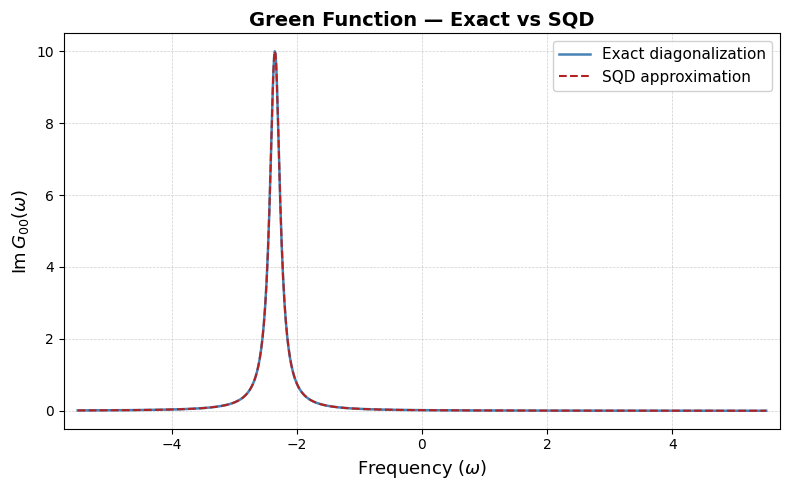

In [18]:
# ===== Liouville-Lanczos =====
from LiouvilleLanczos.Lanczos import Lanczos
from LiouvilleLanczos.Green import CF_Green, PolyLehmann_Green
from LiouvilleLanczos.matrix_impl import (
    MatrixState_inner_product,
    Matrix_Liouvillian,
    Matrix_sum,
)
from LiouvilleLanczos.Quantum_computer.QC_lanczos import Liouvillian_spo, sum_spo
from LiouvilleLanczos.Lanczos import Lanczos
from LiouvilleLanczos.Green import CF_Green, PolyLehmann_Green


def make_green_stack(
    opset_list=["0-123", "1-2"],
    max_iter=10,
    n=4,
    u=4,
    mu=None,
    energy=None,
    backend="exact",
    shots=np.inf,
    eps=1e-17,
    overwrite=False,
):
    stacked_green = None
    abm_dict = {}
    min_iter = 1
    for opset in opset_list:
        a, b, m = get_abmu(
            max_iter, n, u, mu, energy, backend, shots, eps, opset, overwrite
        )
        abm_dict[opset] = (a, b, m)
        min_iter = max(min_iter, len(a))

    for opset, (a, b, m) in abm_dict.items():
        green_list = make_green_list(a, b, m, min_iter)
        if stacked_green is None:
            stacked_green = green_list
        else:
            stacked_green = np.hstack(
                [stacked_green, green_list]
            )  # si ça converge plus vite que le critere on a un probleme
    return stacked_green  # 6 Green par 30it


def annihilation_operators(n):
    c_fermi_list = [
        FermionicOp({f"-_{i}": 1}, num_spin_orbitals=2 * n) for i in range(n)
    ]
    return [MAPPER.map(c) for c in c_fermi_list]


def get_abmu(
    max_iter=10,
    n=4,
    u=4,
    mu=None,
    energy=None,
    backend="exact",
    shots=np.inf,
    eps=1e-17,
    opset="0-123",
    overwrite=False,
):

    c_operators = annihilation_operators(n)

    main_i, other_i = opset.split("-")
    main_op = c_operators[int(main_i)]
    other_ops = [c_operators[int(i)] for i in other_i]

    if backend == "exact":
        _, eigvecs = np.linalg.eigh(hamiltonian.to_matrix())
        ground_state = eigvecs[:, 0]
        lanczos = Lanczos(
            MatrixState_inner_product(ground_state),
            Matrix_Liouvillian(),
            Matrix_sum(),
            logger=None,
        )
        a, b, mm = lanczos.polynomial_hybrid(
            hamiltonian.to_matrix(),
            main_op.to_matrix(),
            [o.to_matrix() for o in other_ops],
            max_iter,
        )
        return a, b, mm

    if backend == "sqd":

        eval = SampledSubspaceProjector(states, coeffs, eps)
        avg_op = eval.inner_product_sqd
        SQ_Liou_avg = Liouvillian_spo(eps)
        lanczos = Lanczos(avg_op, SQ_Liou_avg, sum_spo(eps))

        a, b, mm = lanczos.polynomial_hybrid(
            hamiltonian,
            main_op,
            [o for o in other_ops],
            max_iter,
        )
        return a, b, mm


def make_green_list(a, b, mm, min_iter=1):
    mm = np.asarray(mm)
    num_iterations = len(a)
    num_k = max(num_iterations, min_iter)
    num_moments = len(mm[0])
    green_list = np.empty((num_k, num_moments + 1), dtype=object)
    for k in range(1, num_k + 1):
        kk = min(
            k, num_iterations
        )  ## fill the k > num_iteration with the converged CF_Green
        green_list[k - 1, 0] = CF_Green(a[:kk], b[:kk])
        green0 = green_list[k - 1, 0].to_Lehmann()
        for m in range(num_moments):
            green_list[k - 1, m + 1] = PolyLehmann_Green(
                a[:k], b[:k], mm[:k, m], green0
            )
    return green_list


true_stack_green = make_green_stack(
    ["0-12", "1-02", "2-01"], 31, n, backend="exact", eps=1e-17
)
sqd_stack_green = make_green_stack(
    ["0-12", "1-02", "2-01"], 31, n, backend="sqd", eps=1e-17
)

# ===== Plot Green fonction =====
green_ed = true_stack_green[0][0]
green_sqd = sqd_stack_green[0][0]

w = np.linspace(-5.5, 5.5, 1000) - 1e-1j
w_real = np.real(w)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    w_real,
    np.imag(green_ed(w)),
    color="steelblue",
    linewidth=1.8,
    label=r"Exact diagonalization",
)

ax.plot(
    w_real,
    np.imag(green_sqd(w)),
    color="firebrick",
    linewidth=1.5,
    linestyle="--",
    label=r"SQD approximation",
)

ax.set_xlabel(r"Frequency ($\omega$)", fontsize=13)
ax.set_ylabel(r"$\mathrm{Im}\, G_{00}(\omega)$", fontsize=13)
ax.set_title("Green Function — Exact vs SQD", fontsize=14, fontweight="bold")


ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)


ax.legend(fontsize=11, framealpha=0.9)


ax.margins(x=0.02)

fig.tight_layout()
# plt.savefig("green_function_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

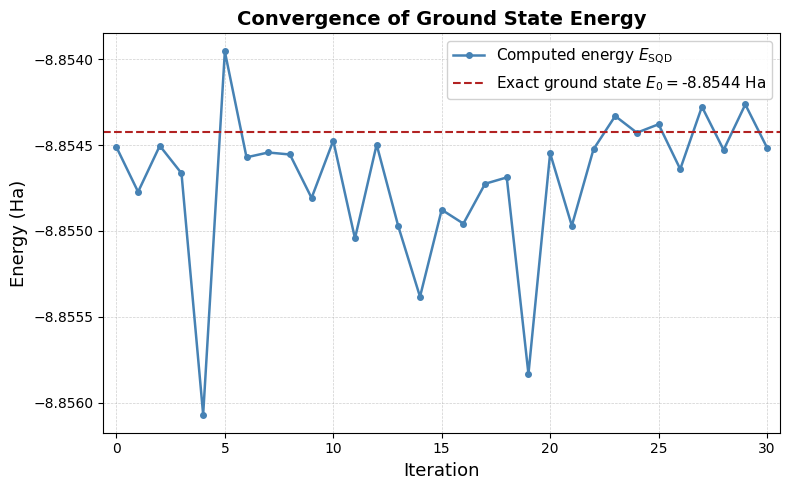

In [ ]:
# ===== Galistkii-Migdal =====
from scipy.sparse import csr_array


def fermi(w):
    return w <= 0.0


green = sqd_stack_green


green_mapping_LiH = [
    (0, 0, 0, 1),
    (0, 1, 1, 1),
    (0, 2, 2, 1),
    (1, 0, 4, 1),
    (1, 1, 3, 1),
    (1, 2, 5, 1),
    (2, 0, 7, 1),
    (2, 1, 8, 1),
    (2, 2, 6, 1),
]

# Galitskii_Migdal_energy
n = len(h0)
num_iterations = len(green)
energy = []
for k in range(0, num_iterations):
    green_list = [g for g in green[k, :]]
    mapping_line = green_mapping_LiH

    # prepare_position_maps
    def convert_matpos(mat_pos):
        r, c, k = mat_pos
        assert r < n
        assert c < n
        assert k < len(green_list)
        return r + c * n, k

    R, C, D = (
        np.zeros(len(mapping_line), dtype=np.int64),
        np.zeros(len(mapping_line), dtype=np.int64),
        np.zeros(len(mapping_line), dtype=np.complex128),
    )
    for i, (il, jl, kl, coeff) in enumerate(mapping_line):
        R[i], C[i] = convert_matpos((il, jl, kl))
        D[i] = coeff
    position_maps = csr_array((D, (R, C)), shape=(n**2, len(green_list)))

    scalar_frequency_weights_function = lambda x: fermi(x)
    matrix_frequency_constant = h0
    GI = np.zeros(len(green_list))
    for i, g in enumerate(green_list):
        if not hasattr(g, "integrate"):
            g = g.to_Lehmann()
        GI[i] = g.integrate(scalar_frequency_weights_function)
    fm = matrix_frequency_constant.flatten()
    Kq = fm @ position_maps @ GI

    scalar_frequency_weights_function = lambda x: x * fermi(x)
    matrix_frequency_constant = np.eye(n)
    GI = np.zeros(len(green_list))
    for i, g in enumerate(green_list):
        if not hasattr(g, "integrate"):
            g = g.to_Lehmann()
        GI[i] = g.integrate(scalar_frequency_weights_function)
    fm = matrix_frequency_constant.flatten()
    wG = fm @ position_maps @ GI

    energy.append((wG + Kq).real)  # /2 missing because spin degeneracy

true_gm_energy = energy


# ===== Plot G-M =====
iterations = np.arange(len(true_gm_energy))

fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(
    iterations,
    true_gm_energy,
    color="steelblue",
    linewidth=1.8,
    marker="o",
    markersize=4,
    label=r"Computed energy $E_{\mathrm{SQD}}$",
)


ax.axhline(
    y=true_gs_energy,
    color="firebrick",
    linewidth=1.5,
    label=r"Exact ground state $E_0 = $" + f"{true_gs_energy:.4f} Ha",
)

ax.axhline(
    y=gs_energie,
    color="darkorange",
    linewidth=1.5,
    linestyle="--",
    label=r"Energy from sampled states $E_{\mathrm{SQD}} = $" + f"{gs_energie:.4f} Ha",
)


ax.set_xlabel("Iteration", fontsize=13)
ax.set_ylabel("Energy (Ha)", fontsize=13)
ax.set_title("Convergence of Ground State Energy", fontsize=14, fontweight="bold")


ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)


ax.legend(fontsize=11, framealpha=0.9)


ax.margins(x=0.02)

fig.tight_layout()
# plt.savefig("energy_convergence.pdf", dpi=300, bbox_inches="tight")
plt.show()